In [1]:
from google.colab import drive

drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


In [3]:
from google.colab import files

data = files.upload()

Saving 600_sample_data - label.csv to 600_sample_data - label.csv


In [4]:
import pandas as pd

df = pd.read_csv("/content/600_sample_data - label.csv")

In [20]:
df.shape

(632, 14)

In [5]:
df = df.rename(columns={
    'Như': 'Annotator1_multi_hop',
    'Nhi': 'Annotator2_multi_hop',
    'Nhật': 'Annotator3_multi_hop'
})

In [6]:
df.columns

Index(['qa_id', 'question', 'entity_count', 'unique_entity_types',
       'entity_types', 'entities', 'is_multihop', 'reasons', 'rule_based',
       'Annotator1_multi_hop', 'Annotator2_multi_hop', 'Annotator3_multi_hop',
       'Unnamed: 12', 'Unnamed: 13'],
      dtype='object')

In [7]:
df = df.drop(columns = ['Unnamed: 12', 'Unnamed: 13'])

In [8]:
cols = ["Annotator1_multi_hop", "Annotator2_multi_hop", "Annotator3_multi_hop"]
for col in cols:
  missing = df[col].isna().sum()
  print(missing)

0
0
0


In [ ]:
# df = df.iloc[:-1]

In [ ]:
df['Annotator1_multi_hop'].head()

,Annotator1_multi_hop
0,multihop
1,multihop
2,multihop
3,multihop
4,multihop


In [9]:
import numpy as np
# Trước khi replace - snapshot
print("=== TRƯỚC KHI REPLACE ===")
for col in ['Annotator1_multi_hop', 'Annotator2_multi_hop', 'Annotator3_multi_hop']:
    print(f"\n{col}:")
    print(df[col].value_counts(dropna=False))

# Replace với xử lý đầy đủ
for col in ['Annotator1_multi_hop', 'Annotator2_multi_hop', 'Annotator3_multi_hop']:
    # Backup
    original = df[col].copy()

    # Làm sạch và replace
    df[col] = df[col].astype(str).str.lower().str.strip()
    df[col] = df[col].replace({
        'multihop': 1,
        'multi-hop': 1,
        'singlehop': 0,
        'single-hop': 0,
        'nan': np.nan
    })

    # Kiểm tra có giá trị lạ không
    valid_values = [0, 1, np.nan]
    invalid_mask = ~df[col].isin(valid_values) & df[col].notna()

    if invalid_mask.any():
        print(f"\n⚠️⚠️⚠️ {col} CÓ GIÁ TRỊ KHÔNG HỢP LỆ:")
        print(df[invalid_mask][[col]])
        print("Giá trị gốc:")
        print(original[invalid_mask])
        # Có thể set thành NaN hoặc dừng lại
        # df.loc[invalid_mask, col] = np.nan

# Sau khi replace - kiểm tra
print("\n=== SAU KHI REPLACE ===")
for col in ['Annotator1_multi_hop', 'Annotator2_multi_hop', 'Annotator3_multi_hop']:
    print(f"\n{col}:")
    print(df[col].value_counts(dropna=False))
    print(f"Data type: {df[col].dtype}")

# Convert sang int (NaN sẽ khiến cột thành float)
for col in ['Annotator1_multi_hop', 'Annotator2_multi_hop', 'Annotator3_multi_hop']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

=== TRƯỚC KHI REPLACE ===

Annotator1_multi_hop:
Annotator1_multi_hop
multihop      535
single-hop     97
Name: count, dtype: int64

Annotator2_multi_hop:
Annotator2_multi_hop
multihop      488
single-hop    144
Name: count, dtype: int64

Annotator3_multi_hop:
Annotator3_multi_hop
multihop      515
single-hop    117
Name: count, dtype: int64

=== SAU KHI REPLACE ===

Annotator1_multi_hop:
Annotator1_multi_hop
1    535
0     97
Name: count, dtype: int64
Data type: int64

Annotator2_multi_hop:
Annotator2_multi_hop
1    488
0    144
Name: count, dtype: int64
Data type: int64

Annotator3_multi_hop:
Annotator3_multi_hop
1    515
0    117
Name: count, dtype: int64
Data type: int64


/tmp/ipython-input-3373772008.py:15: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace({
/tmp/ipython-input-3373772008.py:15: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace({
/tmp/ipython-input-3373772008.py:15: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
 

In [10]:
import numpy as np
import pandas as pd

cols = ["Annotator1_multi_hop", "Annotator2_multi_hop", "Annotator3_multi_hop"]
# 1. Kiểm tra phân bố nhãn của từng annotator
print("Phân bố nhãn:")
for col in cols:
    # Chuyển sang numeric, invalid values sẽ thành NaN
    df[col] = pd.to_numeric(df[col], errors='coerce')
    print(f"{col} - Unique values after conversion: {df[col].unique()}")

# 2. Xem số lượng agreement cases
agreement_count = df[cols].apply(lambda row: len(set(row)) == 1, axis=1).sum()
print(f"Số câu cả 3 người đồng ý: {agreement_count}/{len(df)}")
print(f"Tỷ lệ: {agreement_count/len(df)*100:.2f}%")

# 3. Kiểm tra các trường hợp disagreement
disagreement = df[df[cols].apply(lambda row: len(set(row)) > 1, axis=1)]
print(f"\nSố câu có disagreement: {len(disagreement)}")


Phân bố nhãn:
Annotator1_multi_hop - Unique values after conversion: [1 0]
Annotator2_multi_hop - Unique values after conversion: [1 0]
Annotator3_multi_hop - Unique values after conversion: [1 0]
Số câu cả 3 người đồng ý: 504/632
Tỷ lệ: 79.75%

Số câu có disagreement: 128


In [11]:
# 4. Tính agreement cho từng cặp annotator
from sklearn.metrics import cohen_kappa_score

print("\nCohen's Kappa cho từng cặp:")
print(f"A1-A2: {cohen_kappa_score(df[cols[0]], df[cols[1]]):.3f}")
print(f"A1-A3: {cohen_kappa_score(df[cols[0]], df[cols[2]]):.3f}")
print(f"A2-A3: {cohen_kappa_score(df[cols[1]], df[cols[2]]):.3f}")

# 5. Xem confusion pattern
confusion = pd.crosstab(df[cols[0]], [df[cols[1]], df[cols[2]]])
print("\nConfusion pattern:")
print(confusion)


Cohen's Kappa cho từng cặp:
A1-A2: 0.568
A1-A3: 0.450
A2-A3: 0.649

Confusion pattern:
Annotator2_multi_hop   0       1     
Annotator3_multi_hop   0   1   0    1
Annotator1_multi_hop                 
0                     54  24   4   15
1                     40  26  19  450


In [12]:
df_sub = df[["Annotator1_multi_hop", "Annotator2_multi_hop", "Annotator3_multi_hop"]]
print(df_sub.shape)

(632, 3)


In [13]:
print(df_sub.head())

   Annotator1_multi_hop  Annotator2_multi_hop  Annotator3_multi_hop
0                     1                     1                     1
1                     1                     1                     1
2                     1                     1                     1
3                     1                     1                     1
4                     1                     1                     1


In [14]:
from statsmodels.stats.inter_rater import fleiss_kappa, aggregate_raters
data = df_sub
agg_data, categories = aggregate_raters(data)

print("Bảng tần suất (Subject x Category Counts):")
print(agg_data)
# Ví dụ dòng đầu tiên [0, 0, 0] sẽ thành [3, 0] (3 phiếu cho 0, 0 phiếu cho 1)

# Bước 2: Tính Fleiss' Kappa
kappa = fleiss_kappa(agg_data)

print(f"\nFleiss' Kappa score: {kappa:.4f}")

Bảng tần suất (Subject x Category Counts):
[[0 3]
 [0 3]
 [0 3]
 ...
 [0 3]
 [0 3]
 [3 0]]

Fleiss' Kappa score: 0.5592


In [15]:
# Cách 1: Dùng mode (giá trị xuất hiện nhiều nhất)
from scipy import stats

def majority_vote(row):
    """
    Lấy nhãn xuất hiện nhiều nhất
    Nếu tie (1-1-1 hoặc không có majority), trả về NaN hoặc giá trị đặc biệt
    """
    values = row.values
    # Loại bỏ NaN nếu có
    values = values[~pd.isna(values)]

    if len(values) == 0:
        return np.nan

    # Mode trả về (giá trị mode, số lần xuất hiện)
    mode_result = stats.mode(values, keepdims=True)
    return mode_result.mode[0]

# Áp dụng majority voting
df['final_label'] = df[cols].apply(majority_vote, axis=1)

print("Phân bố nhãn cuối cùng:")
print(df['final_label'].value_counts())
print(f"\nSố câu có nhãn: {df['final_label'].notna().sum()}/{len(df)}")

Phân bố nhãn cuối cùng:
final_label
1    510
0    122
Name: count, dtype: int64

Số câu có nhãn: 632/632


## Validate

In [16]:
import numpy as np
from scipy import stats

# ===== CONFIDENCE INTERVAL =====
n_sample = 632  # số câu trong mẫu
n_multihop = 510  # số câu multi-hop
p_sample = n_multihop / n_sample  # tỷ lệ trong mẫu = 0.944

print("=== CONFIDENCE INTERVAL ===")
print(f"Tỷ lệ multi-hop trong mẫu: {p_sample:.1%}")

# Tính 95% Confidence Interval (Wilson score interval - tốt hơn cho tỷ lệ gần 0 hoặc 1)
def wilson_confidence_interval(successes, n, confidence=0.95):
    """
    Wilson score interval - chính xác hơn cho tỷ lệ cực đoan
    """
    p = successes / n
    z = stats.norm.ppf((1 + confidence) / 2)

    denominator = 1 + z**2 / n
    centre = (p + z**2 / (2*n)) / denominator
    margin = z * np.sqrt((p * (1-p) / n + z**2 / (4*n**2))) / denominator

    return centre - margin, centre + margin

ci_lower, ci_upper = wilson_confidence_interval(n_multihop, n_sample)

print(f"\n95% Confidence Interval: [{ci_lower:.1%}, {ci_upper:.1%}]")
print(f"Margin of Error: ±{(ci_upper - ci_lower)/2:.1%}")
print()
print("Ý nghĩa:")
print(f"→ Với 95% độ tin cậy, tỷ lệ multi-hop trong TOÀN BỘ dataset")
print(f"  nằm trong khoảng {ci_lower:.1%} - {ci_upper:.1%}")

=== CONFIDENCE INTERVAL ===
Tỷ lệ multi-hop trong mẫu: 80.7%

95% Confidence Interval: [77.4%, 83.6%]
Margin of Error: ±3.1%

Ý nghĩa:
→ Với 95% độ tin cậy, tỷ lệ multi-hop trong TOÀN BỘ dataset
  nằm trong khoảng 77.4% - 83.6%


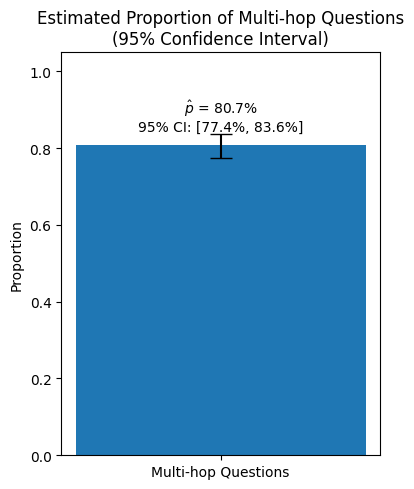

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# ===== DATA =====
n_sample = 632
n_multihop = 510
p_hat = n_multihop / n_sample  # sample proportion

# ===== WILSON CONFIDENCE INTERVAL =====
def wilson_confidence_interval(successes, n, confidence=0.95):
    z = stats.norm.ppf((1 + confidence) / 2)
    p = successes / n

    denominator = 1 + z**2 / n
    centre = (p + z**2 / (2 * n)) / denominator
    margin = (
        z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2))
    ) / denominator

    return centre - margin, centre + margin

ci_lower, ci_upper = wilson_confidence_interval(n_multihop, n_sample)

# ===== PLOT =====
fig, ax = plt.subplots(figsize=(4, 5))

# Bar
ax.bar(
    ["Multi-hop Questions"],
    [p_hat],
    yerr=[[p_hat - ci_lower], [ci_upper - p_hat]],
    capsize=8,
)

# Formatting
ax.set_ylim(0, 1.05)
ax.set_ylabel("Proportion")
ax.set_title("Estimated Proportion of Multi-hop Questions\n(95% Confidence Interval)")

# Annotate value
ax.text(
    0,
    p_hat + 0.03,
    f"$\\hat{{p}}$ = {p_hat:.1%}\n95% CI: [{ci_lower:.1%}, {ci_upper:.1%}]",
    ha="center",
    va="bottom",
    fontsize=10,
)

plt.tight_layout()
plt.show()

In [17]:
df.columns

Index(['qa_id', 'question', 'entity_count', 'unique_entity_types',
       'entity_types', 'entities', 'is_multihop', 'reasons', 'rule_based',
       'Annotator1_multi_hop', 'Annotator2_multi_hop', 'Annotator3_multi_hop',
       'final_label'],
      dtype='object')

In [21]:
full_df = pd.read_csv("/content/drive/MyDrive/DO_AN_DS_KI_1_NAM_3/DS201/NLe/qa_data.csv")

In [22]:
full_df.shape

(6379, 18)

In [23]:
# ===== KIỂM TRA BIAS =====
print("\n=== KIỂM TRA BIAS TRONG LẤY MẪU ===")

# Giả sử bạn có thông tin về toàn bộ dataset
total_dataset_size = 6379  # 234 là 10%

print(f"Tổng dataset: {total_dataset_size} câu")
print(f"Mẫu annotation: {n_sample} câu ({n_sample/total_dataset_size:.1%})")
print()

# Các yếu tố cần kiểm tra bias:
print("CÁC YẾU TỐ CẦN KIỂM TRA:")
print()

# 1. Độ dài câu hỏi
print("1. Độ dài câu (question length):")
print("   - Câu dài có xu hướng multi-hop hơn?")
print("   - So sánh phân bố độ dài giữa mẫu và toàn dataset")
print()

# Ví dụ code kiểm tra (nếu có data)
# Giả sử bạn có cột 'question' và 'question_length'
df['length'] = df['question'].str.len()
full_df['length'] = full_df['question'].str.len()

print(f"Độ dài TB trong mẫu: {df['length'].mean():.1f}")
print(f"Độ dài TB toàn dataset: {full_df['length'].mean():.1f}")

# T-test kiểm tra sự khác biệt
from scipy.stats import ttest_ind
t_stat, p_value = ttest_ind(df['length'], full_df['length'])
print(f"P-value: {p_value:.4f}")
if p_value < 0.05:
    print("⚠️ CÓ SỰ KHÁC BIỆT có ý nghĩa → Mẫu có thể bị bias")
else:
    print("✓ Không có sự khác biệt → Mẫu đại diện về độ dài")


=== KIỂM TRA BIAS TRONG LẤY MẪU ===
Tổng dataset: 6379 câu
Mẫu annotation: 632 câu (9.9%)

CÁC YẾU TỐ CẦN KIỂM TRA:

1. Độ dài câu (question length):
   - Câu dài có xu hướng multi-hop hơn?
   - So sánh phân bố độ dài giữa mẫu và toàn dataset

Độ dài TB trong mẫu: 137.5
Độ dài TB toàn dataset: 138.3
P-value: 0.8650
✓ Không có sự khác biệt → Mẫu đại diện về độ dài


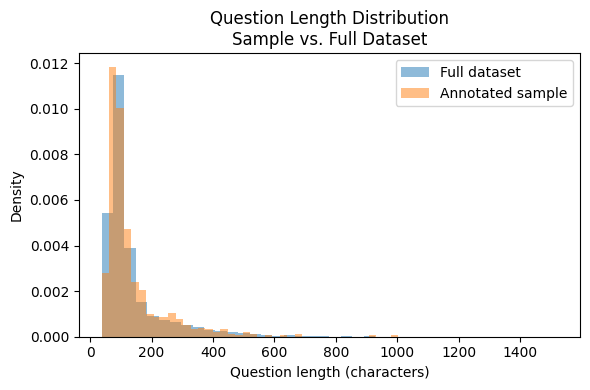

In [27]:
import matplotlib.pyplot as plt

# ===== HISTOGRAM =====
plt.figure(figsize=(6, 4))

plt.hist(
    full_df["length"],
    bins=40,
    density=True,
    alpha=0.5,
    label="Full dataset"
)

plt.hist(
    df["length"],
    bins=40,
    density=True,
    alpha=0.5,
    label="Annotated sample"
)

plt.xlabel("Question length (characters)")
plt.ylabel("Density")
plt.title("Question Length Distribution\nSample vs. Full Dataset")
plt.legend()

plt.tight_layout()
plt.show()

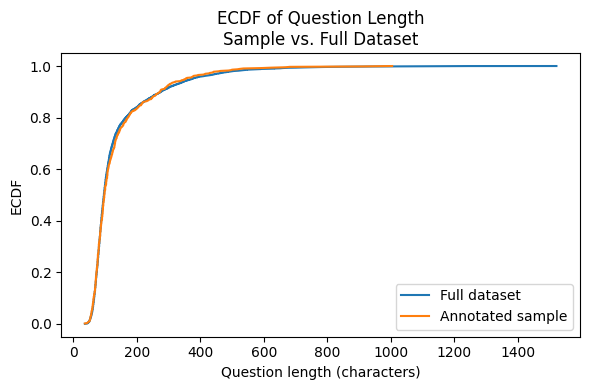

In [26]:
import numpy as np

def ecdf(data):
    x = np.sort(data)
    y = np.arange(1, len(x) + 1) / len(x)
    return x, y

# ===== ECDF DATA =====
x_full, y_full = ecdf(full_df["length"])
x_sample, y_sample = ecdf(df["length"])

# ===== ECDF PLOT =====
plt.figure(figsize=(6, 4))

plt.plot(x_full, y_full, label="Full dataset")
plt.plot(x_sample, y_sample, label="Annotated sample")

plt.xlabel("Question length (characters)")
plt.ylabel("ECDF")
plt.title("ECDF of Question Length\nSample vs. Full Dataset")
plt.legend()

plt.tight_layout()
plt.show()

In [24]:
# ===== STATISTICAL POWER =====
print("=== PHÂN TÍCH STATISTICAL POWER ===")

def sample_size_for_proportion(margin_error, confidence=0.95, p=0.5):
    """
    Tính sample size cần thiết để đạt margin of error mong muốn
    p = 0.5 cho worst case (variance cao nhất)
    """
    z = stats.norm.ppf((1 + confidence) / 2)
    n = (z**2 * p * (1-p)) / (margin_error**2)
    return int(np.ceil(n))

print("Sample size cần thiết cho các mức margin of error:")
for me in [0.01, 0.02, 0.03, 0.05]:
    n_needed = sample_size_for_proportion(me)
    print(f"  Margin ±{me:.1%}: cần {n_needed} câu")

print(f"\nHiện tại bạn có: {n_sample} câu")
print(f"Margin of error thực tế: ±{(ci_upper - ci_lower)/2:.1%}")

if (ci_upper - ci_lower)/2 <= 0.05:
    print("✓ Margin of error chấp nhận được (≤5%)")
else:
    print("⚠️ Margin of error khá lớn, cân nhắc tăng sample size")

=== PHÂN TÍCH STATISTICAL POWER ===
Sample size cần thiết cho các mức margin of error:
  Margin ±1.0%: cần 9604 câu
  Margin ±2.0%: cần 2401 câu
  Margin ±3.0%: cần 1068 câu
  Margin ±5.0%: cần 385 câu

Hiện tại bạn có: 632 câu
Margin of error thực tế: ±3.1%
✓ Margin of error chấp nhận được (≤5%)
